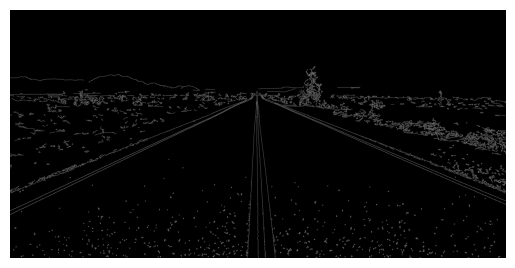

(1524, 3046)
uint8
0
255


In [113]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('images\image.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.axis("off")
plt.show()

print(edges.shape)
print(edges.dtype)
print(edges.min())
print(edges.max())

In [114]:
height = edges.shape[0]
width = edges.shape[1]

print(height, width)

1524 3046


In [115]:
import numpy as np

mask = np.zeros_like(edges)

In [116]:
polygon = np.array([
[
    (0, int(height*0.80)),
    (0, height),
    (width, height),
    (width, int(height*0.75)),
    (width//2, int(height*0.34))
]
])

In [117]:
cv2.fillPoly(mask, polygon, 255)

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

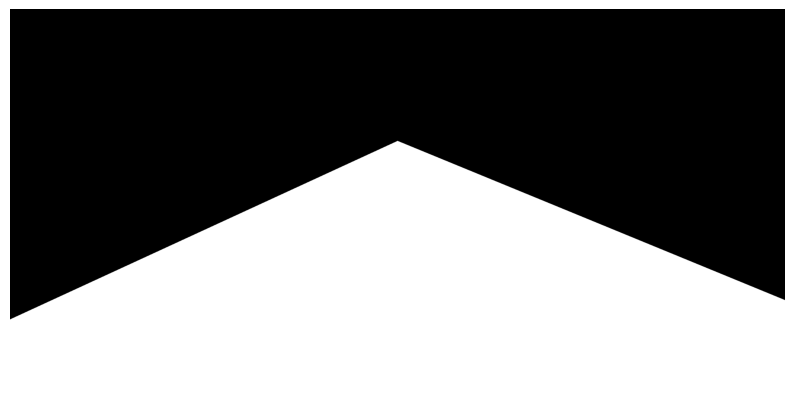

In [118]:
plt.figure(figsize=(10,6))
plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [119]:
cropped = cv2.bitwise_and(edges, mask)

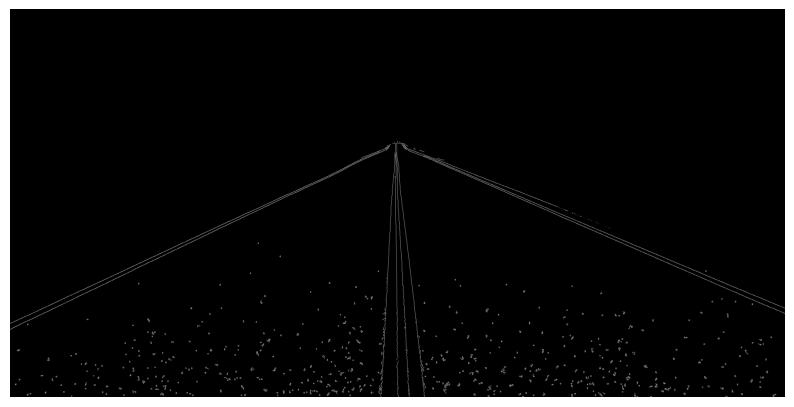

In [120]:
plt.figure(figsize=(10,6))
plt.imshow(cropped, cmap='gray')
plt.axis("off")
plt.show()

In [121]:
lines = cv2.HoughLinesP(
    cropped,
    rho=2,
    theta=np.pi/180,
    threshold=100,
    minLineLength=40,
    maxLineGap=5
)
lines.shape()

TypeError: 'tuple' object is not callable

In [ ]:
print(type(lines))
print(lines.shape)

<class 'numpy.ndarray'>
(72, 1, 4)


In [ ]:
line_image = np.zeros_like(image)

for line in lines:
    x1, y1, x2, y2 = line[0]

    cv2.line(
        line_image,
        (x1,y1),
        (x2,y2),
        (0,255,0),
        5
        )

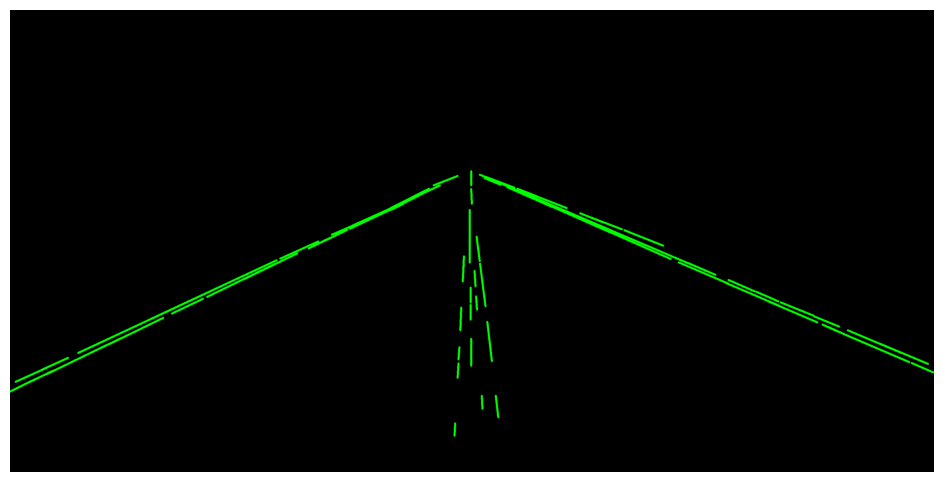

In [ ]:
plt.figure(figsize=(12,6))

plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

In [ ]:
for line in lines:

    x1, y1, x2, y2 = line[0]

    if x1 == x2:
        print("Vertical")
        continue

    slope = (y2-y1) / (x2-x1)

    print(round(slope,2))


0.42
-0.47
-0.49
-0.49
8.67
-25.0
24.5
0.39
-0.49
Vertical
17.0
0.43
-0.47
-13.33
-0.48
21.5
0.44
0.42
0.43
-16.0
-0.47
-0.45
0.43
-19.0
0.42
0.44
-0.45
8.88
0.4
Vertical
0.43
-0.45
Vertical
-0.51
-0.48
14.67
-0.47
7.83
0.38
-20.0
Vertical
0.4
-0.49
-20.5
0.38
0.41
-0.49
-0.45
-0.49
0.44
0.44
0.43
-0.49
0.42
0.46
-0.49
-0.51
-0.43
0.39
8.17
0.38
-0.49
-0.39
0.44
0.4
0.43
Vertical
-0.5
0.42
0.45
8.8
0.44


In [ ]:
left_lines = []
right_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]

    if x1 == x2:
        continue

    slope = (y2-y1) / (x2-x1)

    if -1 < slope < -0.3:
        left_lines.append(line[0])

    elif 0.3 < slope < 1:
        right_lines.append(line[0])

print("Left:", len(left_lines))
print("Right:", len(right_lines))


Left: 24
Right: 28


In [ ]:
lane_debug = np.zeros_like(image)

for x1, y1, x2, y2 in left_lines:

    cv2.line(
        lane_debug,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

for x1, y1, x2, y2 in right_lines:

    cv2.line(
        lane_debug,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

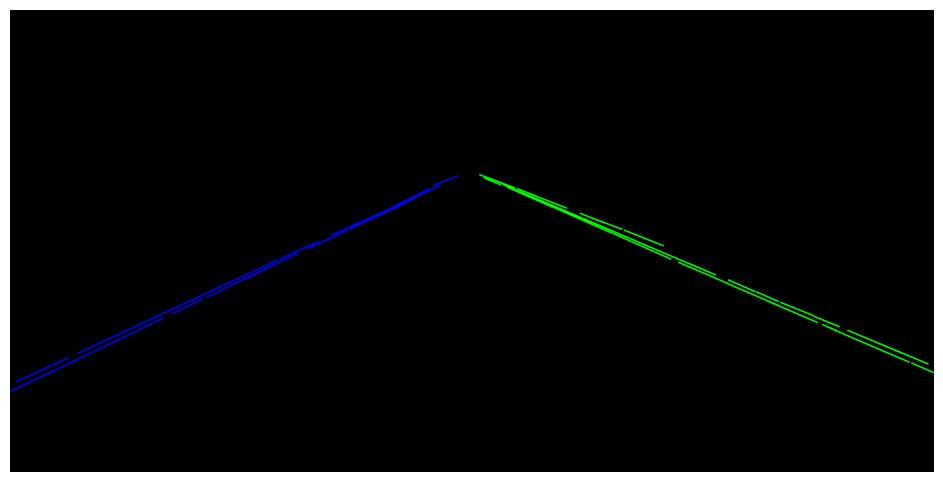

In [ ]:
plt.figure(figsize=(12,6))

plt.imshow(cv2.cvtColor(lane_debug, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

In [ ]:
left_fit = []

for x1, y1, x2, y2 in left_lines:

    fit = np.polyfit(
        (x1, x2),
        (y1, y2),
        1
    )

    left_fit.append(fit)

left_avg = np.average(left_fit, axis=0)

print("Left Avg:", left_avg)

Left Avg: [-4.73814011e-01  1.24757395e+03]


In [ ]:
right_fit = []

for x1, y1, x2, y2 in right_lines:

    fit = np.polyfit(
        (x1, x2),
        (y1, y2),
        1
    )

    right_fit.append(fit)

right_avg = np.average(right_fit, axis=0)

print("Right Avg:", right_avg)

Right Avg: [   0.42027223 -108.11856778]


In [ ]:
def make_coordinates(image, line_parameters):

    slope, intercept = line_parameters

    all_y = []

    for x1, y1, x2, y2 in left_lines + right_lines:
        all_y.extend([y1, y2])

    y1 = max(all_y)
    y2 = min(all_y)

    x1 = int((y1 - intercept)/slope)
    x2 = int((y2 - intercept)/slope)

    return np.array([x1, y1, x2, y2])

In [ ]:
left_line = make_coordinates(image, left_avg)

right_line = make_coordinates(image, right_avg)

print(left_line)
print(right_line)

[ -22 1258 1487  543]
[3250 1258 1549  543]


In [ ]:
lane_image = np.zeros_like(image)

cv2.line(
    lane_image,
    (left_line[0], left_line[1]),
    (left_line[2], left_line[3]),
    (255, 0, 0),
    10
)

cv2.line(
    lane_image,
    (right_line[0], right_line[1]),
    (right_line[2], right_line[3]),
    (0, 255, 0),
    10
)
print()

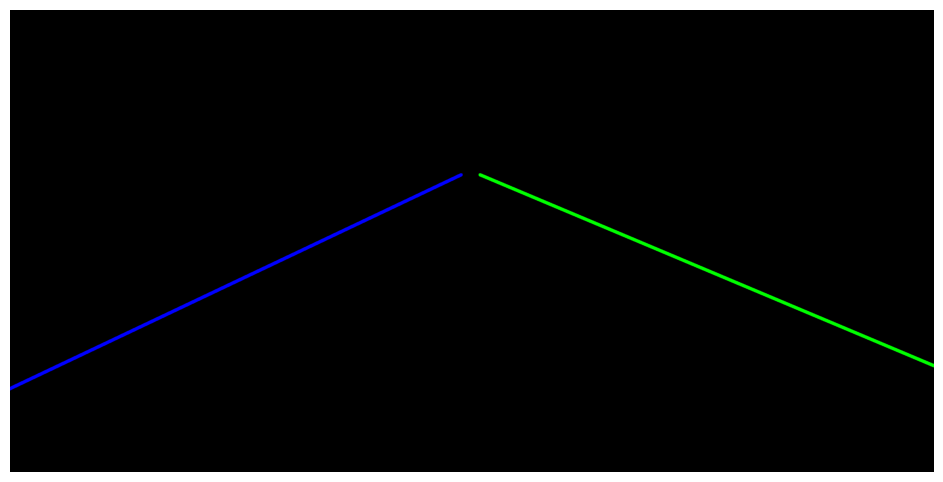

In [ ]:
plt.figure(figsize=(12,6))

plt.imshow(cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

In [ ]:
combo = cv2.addWeighted(
    image,
    0.8,
    lane_image,
    1,
    0
)

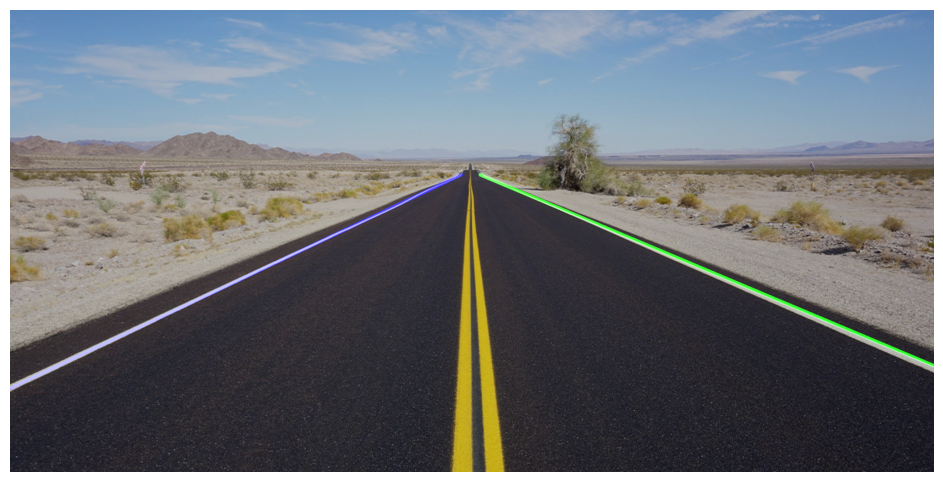

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(combo, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
left_bottom_x = left_line[0]
right_bottom_x = right_line[0]
lane_center = (left_bottom_x + right_bottom_x) // 2
vehicle_center = image.shape[1] // 2

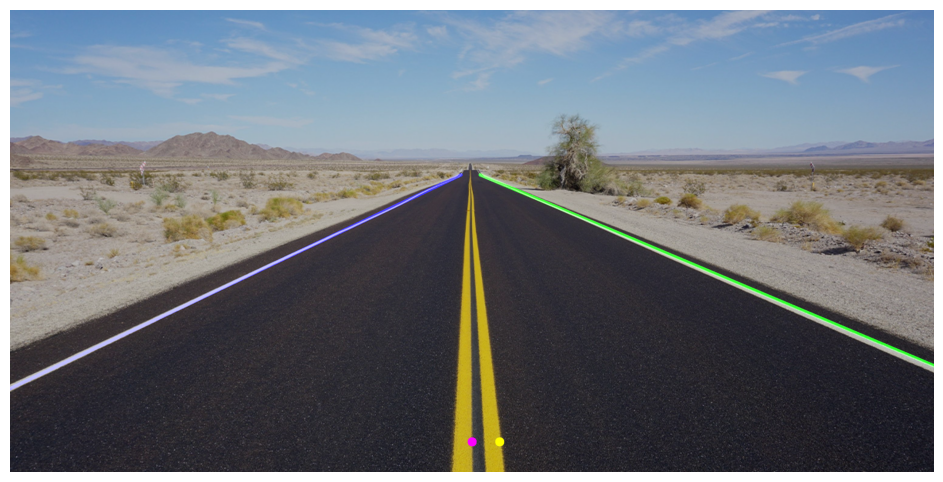

In [ ]:
offset = vehicle_center - lane_center
cv2.circle(
    combo,
    (lane_center, image.shape[0]-100),
    15,
    (0,255,255),
    -1
)
cv2.circle(
    combo,
    (vehicle_center, image.shape[0]-100),
    15,
    (255,0,255),
    -1
)
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(combo, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import carla

client = carla.Client('localhost', 2000)
client.set_timeout(10.0)

world = client.get_world()

print(world.get_map().name)

ModuleNotFoundError: No module named 'carla'

In [122]:
import sys

print(sys.executable)

c:\Users\tanan\AI_ML_Journey\05_DEEP_LEARNING\06_ADAS\01_Lane_Detection\venv\Scripts\python.exe


In [123]:
import os

print(os.getcwd())

c:\Users\tanan\AI_ML_Journey\05_DEEP_LEARNING\06_ADAS\01_Lane_Detection


In [124]:
import sys
print(sys.version)

3.7.9 (tags/v3.7.9:13c94747c7, Aug 17 2020, 18:58:18) [MSC v.1900 64 bit (AMD64)]


In [129]:
import os

for root, dirs, files in os.walk("C:\\"):
    for file in files:
        if file.endswith(".egg") and "carla" in file.lower():
            print(os.path.join(root, file))

C:\Users\tanan\Downloads\CARLA_0.9.14\WindowsNoEditor\PythonAPI\carla\dist\carla-0.9.14-py3.7-win-amd64.egg


In [133]:
import sys

sys.path.append(
    r"C:\Users\tanan\Downloads\CARLA_0.9.14\WindowsNoEditor\PythonAPI\carla\dist\carla-0.9.14-py3.7-win-amd64.egg"
)

import carla

print(carla.__file__)

C:\Users\tanan\Downloads\CARLA_0.9.14\WindowsNoEditor\PythonAPI\carla\dist\carla-0.9.14-py3.7-win-amd64.egg\carla\__init__.py


In [134]:
client = carla.Client('localhost', 2000)
client.set_timeout(10.0)

world = client.get_world()

print(world.get_map().name)

Carla/Maps/Town10HD_Opt


In [135]:
import random

blueprint_library = world.get_blueprint_library()

vehicle_bp = blueprint_library.filter('vehicle.tesla.model3')[0]

spawn_point = random.choice(
    world.get_map().get_spawn_points()
)

vehicle = world.spawn_actor(
    vehicle_bp,
    spawn_point
)

print(vehicle.type_id)

vehicle.tesla.model3


In [136]:
vehicle.set_autopilot(True)

In [137]:
camera_bp = blueprint_library.find('sensor.camera.rgb')

camera_bp.set_attribute('image_size_x', '1280')
camera_bp.set_attribute('image_size_y', '720')
camera_bp.set_attribute('fov', '90')

In [138]:
camera_transform = carla.Transform(
    carla.Location(x=1.5, z=2.4)
)

In [139]:
camera = world.spawn_actor(
    camera_bp,
    camera_transform,
    attach_to=vehicle
)

In [141]:
latest_image = None

import numpy as np

def process_img(image):

    global latest_image

    array = np.frombuffer(
        image.raw_data,
        dtype=np.uint8
    )

    array = array.reshape(
        (image.height, image.width, 4)
    )

    latest_image = array[:, :, :3]

In [142]:
camera.listen(process_img)

In [143]:
print(latest_image.shape)

(720, 1280, 3)


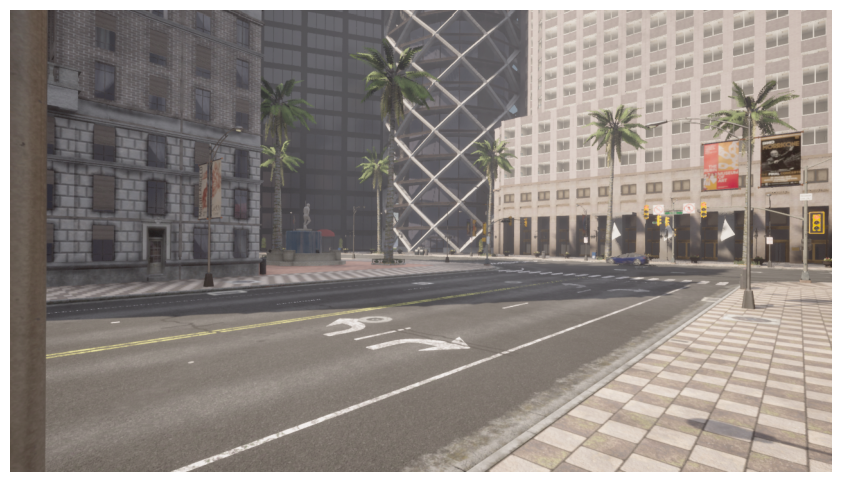

In [213]:
import matplotlib.pyplot as plt

image = cv2.cvtColor(
    latest_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,6))

plt.imshow(image)

plt.axis("off")

plt.show()